# AppleBee — analysis

A mechanistic model of *Osmia cornifrons* reproductive success, evaluated against
two field datasets and then run across the contiguous United States.

| | Analysis | Data |
|---|---|---|
| **1** | Egg production | 17 New York apple orchards, spring 2015 (Centrella et al. 2020) |
| **2** | Whole model | six years of *Osmia* monitoring in Pennsylvania (Turley et al. 2022) |
| **3** | Simulation | 44,756 grid cells × 6 years, thirteen northeastern states |

The model runs four sub-models in sequence — **emergence** (degree-day
accumulation), **egg production** (daily foraging suitability), **larval
development**, and **overwintering mortality**. Analysis 1 supplies observed
emergence and so isolates egg production; analysis 2 predicts every stage.

## Reproducing this

Everything the model reads is in `data/inputs/`, every parameter is a value in a
file you can edit, and both are documented below before any result appears:

- **§ A. Inputs** — each dataset's source, coverage, and the command that
  rebuilds it from that source. Files carry a SHA-256, checked here.
- **§ B. Parameters** — the full parameter set, where each value comes from, and
  how to run the model with your own.

```bash
git clone <repo> && cd AppleBee
pip install -e .
jupyter lab notebooks/applebee_analysis.ipynb
```

Analyses 1 and 2 run from a clone in under a minute. Analysis 3 reads a
simulation output; § 3 gives the command that regenerates it and what it costs.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "applebee").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180, "display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (8, 4.2), "axes.grid": False,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12.5,
                     "xtick.labelsize": 11.5, "ytick.labelsize": 11.5, "legend.fontsize": 11})

from applebee import ModelParams, datasets, provenance
from applebee.config import INPUTS, OUTPUTS
from applebee.evaluation import centrella as C, turley as T

print(f"repository: {ROOT}")
print(f"inputs:     {INPUTS}")

repository: /Users/edwardamoah/Documents/GitHub/AppleBee
inputs:     /Users/edwardamoah/Documents/GitHub/AppleBee/data/inputs


---
# A. Inputs

Three kinds of data, all under `data/inputs/`:

```
data/inputs/
  observations/   field data the model is evaluated against
  weather/        daily PRISM temperature and precipitation, 4 km grid
  forage/         Lonsdorf spring floral resource index, 0-1, per cell per year
```

Nothing in this folder is derived — model outputs go to `outputs/`, and parsed
intermediates to `data/cache/`, both disposable. Each folder carries a
`PROVENANCE.json` giving its source, retrieval date, validation, and a size and
SHA-256 for every file. **Those records are tracked in git even where the bytes
are too large to commit** (the weather matrices run to gigabytes), so a reader who
rebuilds an input from its documented source can check the result against the
same digest this analysis used.

In [2]:
summary = provenance.summary()
display(summary[["input", "dataset", "period", "files", "GB"]])
for _, r in summary.iterrows():
    print(f"\n{r['input']}")
    print(f"  source   : {r['source']}")
    if r["retrieved"]:  print(f"  retrieved: {r['retrieved']}")
    if r["rebuild"]:    print(f"  rebuild  : {r['rebuild']}")
    if r["validated"]:  print(f"  validated: {r['validated']}")

,input,dataset,period,files,GB
0,forage,"Lonsdorf spring floral resource index, 0-1, pe...","2013-2018 (northeast, conus); 2008-2023 (penns...",5,0.35
1,observations,Field observations the model is evaluated against,,2,0.00
2,weather/conus,"PRISM daily 4 km, contiguous United States (la...",2013-01-01..2018-12-31,6,8.44
3,weather/northeast,"PRISM daily 4 km, Northeast",2013-01-01..2018-12-31,6,1.80
4,weather/pennsylvania,"PRISM daily 4 km, Pennsylvania",1990-01-01..2024-07-01,6,0.75



forage
  source   : USDA Cropland Data Layer (https://www.nass.usda.gov/Research_and_Science/Cropland/Release/datasets/{year}_30m_cdls.zip) scored with Koh et al. (2016) expert spring values
  retrieved: 2026-08-07/08 (northeast, conus); pa and ny inherited with the dissertation
  rebuild  : python scripts/build_forage.py --region {conus|northeast} --years 2013 2018 --source national

observations
  source   : published datasets, see per_file below
  retrieved: inherited with the dissertation; re-filed here 2026-08-08
  rebuild  : re-download from the cited sources; both files are small enough to be tracked in git, so a clone already has them

weather/conus
  source   : https://services.nacse.org/prism/data/get/us/4km/{variable}/{YYYYMMDD}
  retrieved: 2026-08-07/08
  rebuild  : ~9 GB re-download, ~9 h, subject to PRISM's 2-downloads-per-file-per-24h limit

weather/northeast
  source   : https://services.nacse.org/prism/data/get/us/4km/{variable}/{YYYYMMDD}
  retrieved: 2026-08-06/07


### Integrity

`verify()` compares what is on disk against those records. Sizes are instant;
`full=True` hashes every byte, which is minutes for the multi-gigabyte weather
matrices, so the fast check runs by default and the observations and forage
tables — the files a reader is most likely to modify — are hashed in full.

In [3]:
provenance.report()                                   # every input, by size
print()
provenance.report("observations", full=True)          # SHA-256
provenance.report("forage", full=True)

25 files checked by size: 25 size ok, not hashed

2 files checked by SHA-256: 2 ok


5 files checked by SHA-256: 5 ok


,input,file,GB,status
0,forage,pa_forage_spring_lonsdorf.csv,0.007,ok
1,forage,ny_forage_spring_2015_sites.csv,0.000,ok
2,forage,koh_2016_cdl_floral_index.csv,0.000,ok
3,forage,conus_forage_spring_lonsdorf.csv,0.294,ok
4,forage,northeast_forage_spring_lonsdorf.csv,0.044,ok


### Regenerating an input from its source

The weather and forage inputs were fetched and built by scripts in this
repository, not hand-assembled. Both take `--dry-run`, which reports the download
volume and cell count without fetching anything.

```bash
# daily PRISM temperature and precipitation, 4 km grid
python scripts/fetch_prism.py --region northeast --start 2013-01-01 --end 2018-12-31 \
       --variables tmean ppt --dry-run

# Lonsdorf spring forage index from the USDA national Cropland Data Layer
python scripts/build_forage.py --region northeast --years 2013 2018 --source national --dry-run
```

`fetch_prism.py` writes float32 matrices directly and can discard the source
rasters (`--discard-rasters`); it resumes by verifying every cell of each day
already written, so an interrupted fetch continues rather than restarting.
`build_forage.py` writes per-year partials, so a rebuild only redoes what is
missing.

**PRISM allows two fetches per file per 24 hours**, so a full re-download is
hours of wall-clock, not minutes. The observations are small enough to be tracked
in git; a clone already has them.

### The forage index

Not a raw input but not a model output either — it is derived from two public
sources, both tracked:

| Source | Role |
|---|---|
| USDA Cropland Data Layer, 30 m | land-cover class per pixel |
| Koh et al. (2016) expert values | spring floral value per class, 0–1 |

For each grid cell, land-cover fractions within the foraging radius are dotted
with the Koh spring index — an area-weighted mean, computed with `exactextract`
in EPSG:5070. The model uses the **1 km** radius; 3 km and 5 km are also built
and available in the same files.

In [4]:
koh = pd.read_csv(INPUTS / "forage" / "koh_2016_cdl_floral_index.csv")
spring = koh[["value", "class_name", "floral_resources_spring_index"]].rename(
    columns={"value": "CDL class", "floral_resources_spring_index": "spring index"})
print(f"{len(koh)} CDL classes scored; the model uses the spring column\n")
print("highest-valued spring forage:")
display(spring.nlargest(6, "spring index").reset_index(drop=True))
print("lowest, excluding class 0 (Background), which is treated as nodata rather than zero:")
display(spring[spring["CDL class"] > 0].nsmallest(4, "spring index").reset_index(drop=True))

134 CDL classes scored; the model uses the spring column

highest-valued spring forage:


,CDL class,class_name,spring index
0,64,Shrubland,0.699347
1,152,Shrubland,0.699347
2,141,Deciduous Forest,0.696528
3,58,Clover/Wildflowers,0.692830
4,55,Caneberries,0.618410
5,242,Blueberries,0.618410


lowest, excluding class 0 (Background), which is treated as nodata rather than zero:


,CDL class,class_name,spring index
0,81,Clouds/No Data,0.0
1,83,Water,0.0
2,88,Nonag/Undefined,0.0
3,92,Aquaculture,0.0


### What is on disk, and what each region can run

A dataset is a region's weather plus its forage index. The runnable cell set is
the **intersection** of the two — a cell with weather but no forage index would
otherwise fail deep inside the model — and the usable year range is derived from
the files themselves: a year needs a full calendar of weather (the emergence
search reads from 1 January) and a forage index. Offspring are reported for the
following spring.

In [5]:
display(datasets.describe()[["dataset", "description", "available", "cells",
                             "weather_years", "offspring_springs"]])
print("adding a region is one entry in applebee/datasets.py — the loader, the")
print("usable years and the runnable cells are all derived from its files.")

,dataset,description,available,cells,weather_years,offspring_springs
0,pennsylvania,"the chapter's own extent: 7,452 cells, 1990-2024",True,7452,2008-2023,2009-2024
1,northeast,"13 states, 2013-2018",True,44759,2013-2018,2014-2019
2,conus,every land cell of the contiguous United State...,True,474268,2013-2018,2014-2019


adding a region is one entry in applebee/datasets.py — the loader, the
usable years and the runnable cells are all derived from its files.


---
# B. Model parameters

Every parameter is a field of `ModelParams`, a frozen dataclass with no hidden
state. Nothing in the model reads a global or a hard-coded constant, so the
parameter set below is the complete specification of a run.

Three ways to supply them:

```python
ModelParams()                                    # literature defaults, used throughout
ModelParams().with_(longevity=24)                # change one, keep the rest
ModelParams.from_file("my_run.toml")             # JSON or TOML, name only what changes
```

```toml
# my_run.toml — everything unnamed keeps its default
temperature_threshold = 18.72
longevity             = 24
```

```bash
python scripts/simulate.py --region conus --params my_run.toml
```

A misspelled key **raises** rather than silently falling back to the default — a
run that looks configured and is not would be worse than a stop. Every simulation
writes the exact parameters it used to `{output}.params.json` beside its results.

In [6]:
import dataclasses
SOURCE = {
    "emergence_base_temp":        "degree-day base for spring emergence (°C)",
    "emergence_thermal_constant": "accumulated degree-days to emergence",
    "emergence_start_doy":        "day of year accumulation begins",
    "mating_days":                "days after emergence before nesting starts",
    "longevity":                  "adult female lifespan (days)",
    "temperature_threshold":      "minimum mean temperature for a foraging day (°C)",
    "precipitation_threshold":    "rainfall that prevents foraging (mm)",
    "forage_threshold":           "Lonsdorf index above which a cell is forage-abundant",
    "eggs_high_forage":           "eggs laid on a suitable day, forage-abundant cell",
    "eggs_low_forage":            "eggs laid on a suitable day, forage-poor cell",
    "egg_larva_days":             "days from egg to larval development",
    "mortality_factor":           "larval mortality per unsuitable development day",
    "lower_dev_threshold":        "lower bound of larval development (°C)",
    "upper_dev_threshold":        "upper bound of larval development (°C)",
    "prewinter_start":            "pre-wintering period begins (month, day)",
    "prewinter_end":              "pre-wintering period ends (month, day)",
    "diapause_temp_threshold":    "temperature below which diapause proceeds (°C)",
    "winter_mortality_factor":    "overwintering mortality per unsuitable day",
}
p = ModelParams()
display(pd.DataFrame([{"parameter": f.name, "default": getattr(p, f.name),
                       "meaning": SOURCE[f.name]}
                      for f in dataclasses.fields(p)]))

,parameter,default,meaning
0,emergence_base_temp,6.53,degree-day base for spring emergence (°C)
1,emergence_thermal_constant,209.0,accumulated degree-days to emergence
2,emergence_start_doy,1,day of year accumulation begins
3,mating_days,2,days after emergence before nesting starts
4,longevity,22,adult female lifespan (days)
5,temperature_threshold,13.9,minimum mean temperature for a foraging day (°C)
6,precipitation_threshold,5.0,rainfall that prevents foraging (mm)
7,forage_threshold,0.5,Lonsdorf index above which a cell is forage-ab...
8,eggs_high_forage,2,"eggs laid on a suitable day, forage-abundant cell"
9,eggs_low_forage,1,"eggs laid on a suitable day, forage-poor cell"


An alternative set calibrated on the New York orchard data is included for
comparison. `differences()` reports only what it changes, so a configuration is
always readable as a diff against the literature values.

In [7]:
for name, (was, now) in ModelParams.calibrated().differences().items():
    print(f"  {name:24s} {was}  ->  {now}")

# Round-trips through a file, so a configuration can be committed beside a result.
tmp = Path("example_params.toml")
tmp.write_text("temperature_threshold = 18.72\nlongevity = 24\n")
custom = ModelParams.from_file(tmp)
print(f"\nfrom {tmp.name}: temperature_threshold {custom.temperature_threshold}, "
      f"longevity {custom.longevity}, "
      f"precipitation_threshold {custom.precipitation_threshold} (default, unnamed)")
tmp.unlink()

  temperature_threshold    13.9  ->  18.72
  precipitation_threshold  5.0  ->  4.33
  forage_threshold         0.5  ->  0.54

from example_params.toml: temperature_threshold 18.72, longevity 24, precipitation_threshold 5.0 (default, unnamed)


---
# 1. Egg production — New York orchards, 2015

17 Finger Lakes apple orchards, each stocked with roughly 100 *O. cornifrons* on
5 May 2015. Emergence began 7 May and nest tubes were collected at three time
points to 24 June, giving **51 observations = 17 sites × 3 collection windows**.

Because emergence is observed rather than predicted, this isolates the egg
production sub-model: a female lays `eggs_high_forage` eggs on a day that is warm
enough, dry enough, and in a forage-abundant cell, and `eggs_low_forage`
otherwise.

**Collection window.** Each window is the six days **ending on and including**
the collection date — the interval `[D-5, D]`. Excluding the collection day
instead loses a run of six fully favourable days at the end of May, present at
every site, and caps predicted eggs at 10 rather than 12.

**Response variable.** The dataset records *emerged adults*, not brood cells. The
model predicts cells, so cells are reconstructed as

$$\text{cells} = \frac{\text{males} + \text{females}}{1 - \text{larval mortality}}$$

which is exact where mortality is recorded and a lower bound on the 11 of 51 rows
that record none.

In [8]:
data = C.load_centrella()
design = C.build_design(data, ModelParams())
print(f"{len(design)} observations, {design.Site.nunique()} sites, "
      f"{design.Time_Point.nunique()} collection windows")
print(f"predicted eggs per female: {design.predicted_eggs.min()}-{design.predicted_eggs.max()}\n")

display(data.observations.observed_eggs.describe()[["count", "mean", "std", "min", "max"]]
        .to_frame("reconstructed brood cells").round(1).T)

51 observations, 17 sites, 3 collection windows
predicted eggs per female: 1-12



,count,mean,std,min,max
reconstructed brood cells,51.0,51.6,41.2,4.0,182.4


### Fit

Observed cells against predicted eggs, with collection time point as a fixed
effect and a **random intercept by site** — 51 observations across 17 sites, so
the variance components are identifiable.

$$\text{cells}_{ij} = \beta_0 + \beta_1\,\text{eggs}_{ij} + \gamma_{t(ij)} + u_i + \varepsilon_{ij},
\qquad u_i \sim N(0, \sigma_u^2)$$

In [9]:
fit = C.fit_lme(design)
fitted = np.asarray(fit.fittedvalues)
y = design.observed_eggs.to_numpy(float)
sst = ((y - y.mean()) ** 2).sum()

print(f"  slope           {float(fit.params['predicted_eggs']):.2f} brood cells per predicted egg"
      f"   (p = {float(fit.pvalues['predicted_eggs']):.4f})")
print(f"  site variance   {float(fit.cov_re.iloc[0, 0]):.1f}")
print(f"  residual        {float(fit.scale):.1f}")
print(f"  ICC             {float(fit.cov_re.iloc[0, 0]) / (float(fit.cov_re.iloc[0, 0]) + float(fit.scale)):.3f}"
      "   <- share of variance between sites\n")
r2 = lambda v: 1 - ((y - v) ** 2).sum() / sst
print(f"  R2              {r2(fitted):.3f}   <- conditional: fixed effects and site intercepts")

  slope           7.92 brood cells per predicted egg   (p = 0.0036)
  site variance   306.8
  residual        1049.8
  ICC             0.226   <- share of variance between sites

  R2              0.510   <- conditional: fixed effects and site intercepts


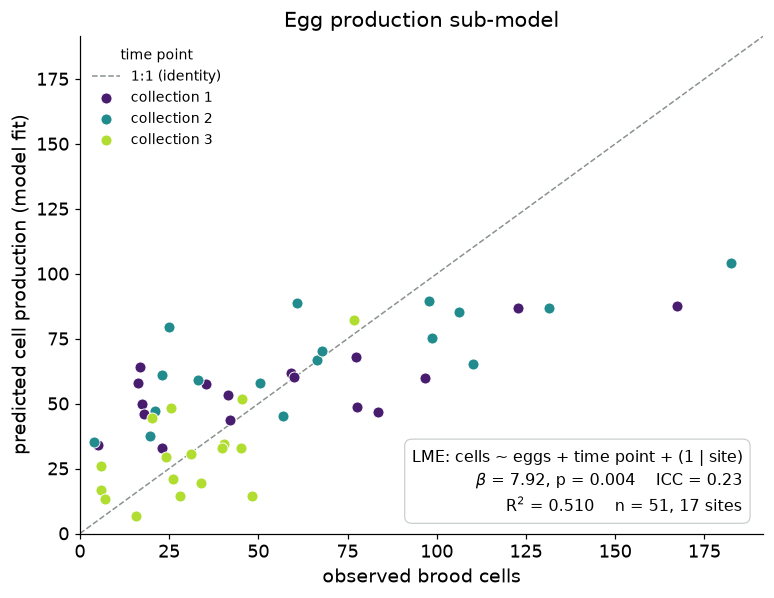

In [10]:
# The y axis is the fit of a mixed-effects model, not a straight line through the
# points, so the specification is stated on the figure -- the dashed line is the
# identity, against which a fit is judged, and not a regression line.
icc = float(fit.cov_re.iloc[0, 0]) / (float(fit.cov_re.iloc[0, 0]) + float(fit.scale))
SPEC = ("LME: cells ~ eggs + time point + (1 | site)\n"
        f"$\\beta$ = {float(fit.params['predicted_eggs']):.2f}, "
        f"p = {float(fit.pvalues['predicted_eggs']):.3f}    ICC = {icc:.2f}\n"
        f"R$^2$ = {r2(fitted):.3f}    n = {len(design)}, {design.Site.nunique()} sites")

# Time point is the collection window (1, 2, 3), a category rather than a
# quantity, so it gets three discrete colours and a legend.
points = sorted(design.Time_Point.unique())
colours = dict(zip(points, plt.cm.viridis(np.linspace(.08, .88, len(points)))))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
lim = [0, max(design.observed_eggs.max(), fitted.max()) * 1.05]
ax.plot(lim, lim, ls="--", color="#8a938d", lw=1, zorder=1, label="1:1 (identity)")
for tp in points:
    m = (design.Time_Point == tp).to_numpy()
    ax.scatter(design.observed_eggs[m], fitted[m], color=colours[tp], s=52,
               edgecolor="white", lw=.6, zorder=3, label=f"collection {tp}")
ax.set(xlim=lim, ylim=lim, xlabel="observed brood cells",
       ylabel="predicted cell production (model fit)",
       title="Egg production sub-model")
ax.legend(frameon=False, fontsize=9, loc="upper left", title="time point",
          title_fontsize=9)
ax.text(.97, .035, SPEC, transform=ax.transAxes, ha="right", va="bottom", fontsize=10.5,
        linespacing=1.45, bbox=dict(boxstyle="round,pad=.45", fc="white", ec="#c9cfcb", lw=.8))
plt.tight_layout(); plt.show()

### Sensitivity to the parameter set

The same fit under the calibrated thresholds. The two are close, which is worth
stating plainly: over the region of parameter space these two sets occupy, the
fit is flat, so the calibrated optimum is not sharply identified.

In [11]:
rows = []
for tag, params in [("literature defaults", ModelParams()),
                    ("calibrated", ModelParams.calibrated())]:
    r = C.evaluate(params, data)
    rows.append({"parameters": tag, "conditional R2": round(r["r2"], 3),
                 "max predicted eggs": int(C.build_design(data, params).predicted_eggs.max())})
display(pd.DataFrame(rows))

,parameters,conditional R2,max predicted eggs
0,literature defaults,0.510,12
1,calibrated,0.521,4


---
# 2. Whole model — Pennsylvania, 2014–2019

Blue vane traps at eight locations around the Penn State Fruit Research and
Extension Center in Adams County, sampled weekly from April to October. All eight
fall inside one 4 km grid cell, so the response is **one *Osmia* count per year,
six in total**.

Every sub-model runs here, and emergence is predicted rather than observed. The
model is driven only by that cell's daily weather and its annual forage index.

In [12]:
model = datasets.get("pennsylvania").model()
results = {}
for tag, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    model.params = params
    results[tag] = T.evaluate(model)
model.params = ModelParams()

d3 = results["default"]["design"]
display(d3[["year", "observed", "predicted", "eggs", "emergence_doy"]])
print(f"  R2 {results['default']['r2']:.3f}, RMSE {results['default']['rmse']:.2f} (defaults)")
print(f"  R2 {results['calibrated']['r2']:.3f}, RMSE {results['calibrated']['rmse']:.2f} (calibrated)")

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,year,observed,predicted,eggs,emergence_doy
0,2014,10,8.4600,11,127
1,2015,58,11.6675,13,130
2,2016,47,11.5375,14,126
3,2017,26,1.5975,2,118
4,2018,27,2.9700,7,110
5,2019,15,8.8500,10,128


  R2 0.803, RMSE 7.52 (defaults)
  R2 0.797, RMSE 7.63 (calibrated)


### Fit

Same structure as § 1 — observed count on predicted offspring per female, with a
random intercept by year:

$$\text{count}_t = \beta_0 + \beta_1\,\text{offspring}_t + u_t + \varepsilon_t,
\qquad u_t \sim N(0, \sigma_u^2)$$

In [13]:
fit3 = results["default"]["fit"]
y3 = d3.observed.to_numpy(float); sst3 = ((y3 - y3.mean()) ** 2).sum()
fitted3 = np.asarray(fit3.fittedvalues)
fixed3 = (fit3.params["Intercept"] + fit3.params["predicted"] * d3.predicted).to_numpy()
ols = stats.linregress(d3.predicted, d3.observed)

print(f"  slope                {float(fit3.params['predicted']):.2f}")
print(f"  R2                   {1 - ((y3 - fitted3) ** 2).sum() / sst3:.3f}   <- conditional")
print(f"  RMSE                 {results['default']['rmse']:.2f}\n")
print("  diagnostics on the design, not reported statistics:")
print(f"    variance components  group {float(fit3.cov_re.iloc[0, 0]):.4f}, "
      f"residual {float(fit3.scale):.4f}   <- identical")
print(f"    standard error       mixed model {float(fit3.bse['predicted']):.3f}, "
      f"OLS {ols.stderr:.3f}")
print(f"    fixed effects alone  R2 {1 - ((y3 - fixed3) ** 2).sum() / sst3:.3f}")

  slope                1.99
  R2                   0.803   <- conditional
  RMSE                 7.52

  diagnostics on the design, not reported statistics:
    variance components  group 169.5554, residual 169.5554   <- identical
    standard error       mixed model 0.618, OLS 1.922
    fixed effects alone  R2 0.212


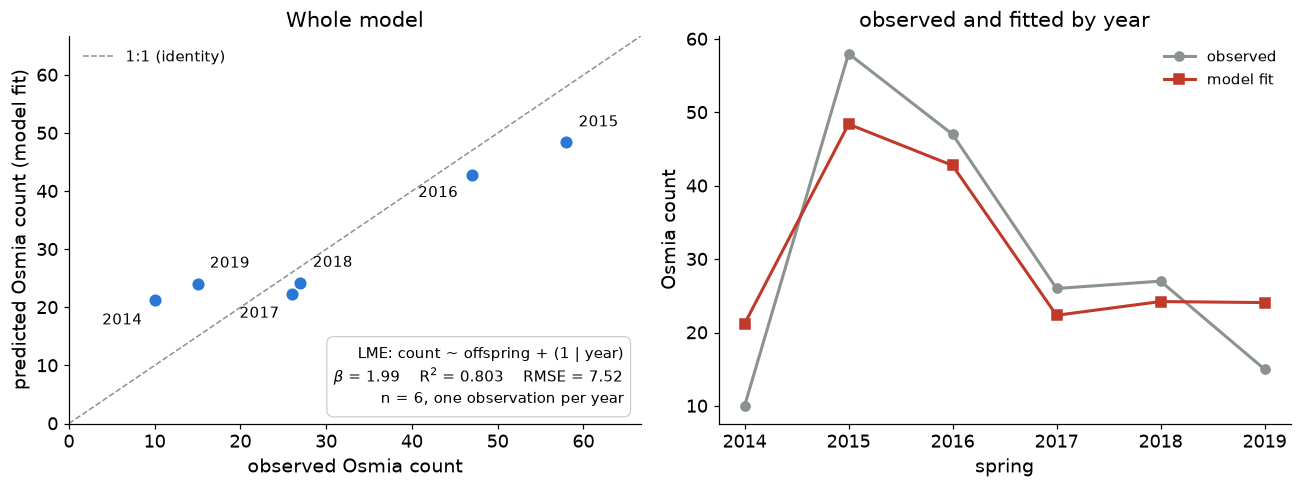

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
lim = [0, max(d3.observed.max(), fitted3.max()) * 1.15]
axes[0].plot(lim, lim, ls="--", color="#8a938d", lw=1, zorder=1, label="1:1 (identity)")
axes[0].scatter(d3.observed, fitted3, s=80, color="#2a78d6", edgecolor="white", zorder=3)
# 2017 and 2018 sit almost on top of each other, so a fixed offset collides.
# Each label is placed in whichever of eight directions is furthest from the
# other points and from labels already placed.
pts = np.column_stack([d3.observed.to_numpy(float), fitted3])
pad = (lim[1] - lim[0]) * .045
dirs = [(1, .35), (1, -.75), (-1, .35), (-1, -.75), (.1, 1), (.1, -1), (.9, .9), (-.9, -.9)]
placed = []
for i, (px, py) in enumerate(pts):
    others = np.delete(pts, i, axis=0)
    best, best_score = dirs[0], -np.inf
    for dx, dy in dirs:
        anchor = np.array([px + dx * pad, py + dy * pad])
        if not (lim[0] <= anchor[0] <= lim[1] and lim[0] <= anchor[1] <= lim[1]):
            continue
        near = np.vstack([others, placed]) if placed else others
        score = np.min(np.hypot(*(near - anchor).T))
        if score > best_score:
            best, best_score = (dx, dy), score
    dx, dy = best
    placed.append([px + dx * pad, py + dy * pad])
    axes[0].annotate(int(d3.year.iloc[i]), (px, py), fontsize=10,
                     xytext=(dx * 9, dy * 9), textcoords="offset points",
                     ha="left" if dx > .2 else "right" if dx < -.2 else "center",
                     va="bottom" if dy > 0 else "top")
axes[0].set(xlim=lim, ylim=lim, xlabel="observed Osmia count",
            ylabel="predicted Osmia count (model fit)", title="Whole model")
axes[0].legend(frameon=False, fontsize=10, loc="upper left")
axes[0].text(.97, .035,
             "LME: count ~ offspring + (1 | year)\n"
             f"$\\beta$ = {float(fit3.params['predicted']):.2f}    "
             f"R$^2$ = {results['default']['r2']:.3f}    "
             f"RMSE = {results['default']['rmse']:.2f}\n"
             f"n = {len(d3)}, one observation per year",
             transform=axes[0].transAxes, ha="right", va="bottom", fontsize=10,
             linespacing=1.45,
             bbox=dict(boxstyle="round,pad=.45", fc="white", ec="#c9cfcb", lw=.8))

axes[1].plot(d3.year, d3.observed, marker="o", color="#8a938d", lw=2, label="observed")
axes[1].plot(d3.year, fitted3, marker="s", color="#c0392b", lw=2, label="model fit")
axes[1].set(xlabel="spring", ylabel="Osmia count", title="observed and fitted by year")
axes[1].legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.show()

The model tracks the observed series, and the effect of predicted offspring on
*Osmia* abundance is positive.

**A caveat on precision, not on the fit.** There is one observation per year and
the random intercept is by year, so each intercept is estimated from a single
number. Under that design the group and residual variance components are not
separable — the diagnostics above show them coming out identical — and the
standard error on the slope is correspondingly optimistic. Six annual counts from
one site cannot support a strong claim of statistical significance either way,
and the p-value from this fit should be treated with caution.

This is a limitation of the evaluation data rather than of the model. A panel
with genuine replication — several sites over several years, so that year effects
are estimated from more than one observation each — would resolve it. The
simulation below produces exactly that structure and is the natural place to take
this next.

---
# 3. Simulation — Northeast, 2014–2019

Every land cell in the thirteen northeastern states carrying both weather and a
forage index: **44,756 cells × 6 years = 268,536 cell-years**. Weather years
2013–2018 give offspring for springs 2014–2019.

The extent is deliberately the Northeast rather than the whole country. Both
evaluations in § 1 and § 2 are northeastern — New York orchards and a
Pennsylvania monitoring site — so this is the region where the model has been
tested against observations. It also avoids a known weakness at low latitudes:
the foraging criterion is applied to **daily mean** temperature, and where the
diurnal range is wide a day averaging below the threshold may still have had a
usable afternoon, so unsuitable days are over-counted where mornings are cold and
afternoons warm.

```bash
python scripts/simulate.py --region northeast                      # literature defaults
python scripts/simulate.py --region northeast --params calibrated
python scripts/simulate.py --region northeast --params my_run.toml --dry-run
```

Writes `outputs/northeast_simulation.parquet` and, beside it,
`northeast_simulation.params.json` — the exact parameter set used, so a result is
never separated from its configuration. The cached result is read here.

In [15]:
SIM = OUTPUTS / "northeast_simulation.parquet"
if not SIM.exists():
    raise SystemExit("run: python scripts/simulate.py --region northeast")

ne = pd.read_parquet(SIM, columns=["col", "row", "offspring", "offspring_year", "lat", "lon",
                                   "eggs", "emergence_doy", "no_egg_days_temperature",
                                   "no_egg_days_precipitation"])
per_cell = ne.groupby(["col", "row"]).agg(mean=("offspring", "mean"), sd=("offspring", "std"),
                                          lat=("lat", "first"), lon=("lon", "first"))
used = SIM.with_suffix(".params.json")
if used.exists():
    print(f"parameters used: {ModelParams.from_file(used).differences() or 'literature defaults'}")
print(f"{len(ne):,} cell-years, {len(per_cell):,} cells, "
      f"springs {ne.offspring_year.min()}-{ne.offspring_year.max()}\n")
print(f"  offspring per female: mean {ne.offspring.mean():.2f}, "
      f"range {ne.offspring.min():.1f}-{ne.offspring.max():.1f}")
print(f"  eggs per female:      mean {ne.eggs.mean():.2f}")
print(f"  variation across space (SD of cell means)     {per_cell['mean'].std():.2f}")
print(f"  variation through time (mean within-cell SD)  {per_cell['sd'].mean():.2f}")

268,536 cell-years, 44,756 cells, springs 2014-2019

  offspring per female: mean 14.73, range 0.0-34.8
  eggs per female:      mean 17.27
  variation across space (SD of cell means)     4.59
  variation through time (mean within-cell SD)  4.99


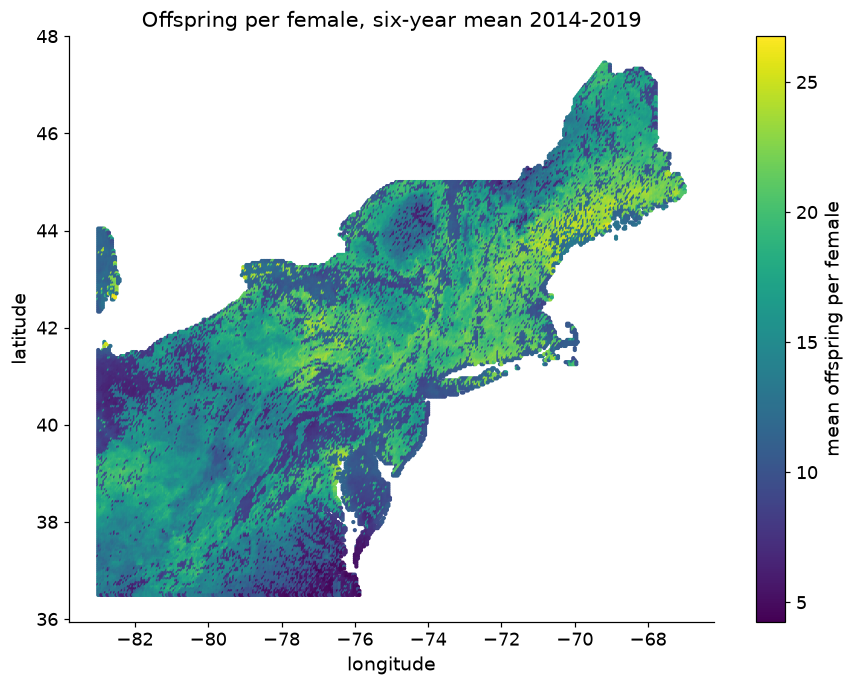

In [16]:
ASPECT = 1 / np.cos(np.radians(41))

fig, ax = plt.subplots(figsize=(8.5, 6.4))
sc = ax.scatter(per_cell.lon, per_cell.lat, c=per_cell["mean"], s=3, cmap="viridis")
fig.colorbar(sc, ax=ax, label="mean offspring per female", fraction=.035)
ax.set(xlabel="longitude", ylabel="latitude",
       title="Offspring per female, six-year mean 2014-2019")
ax.set_aspect(ASPECT)
plt.tight_layout(); plt.show()

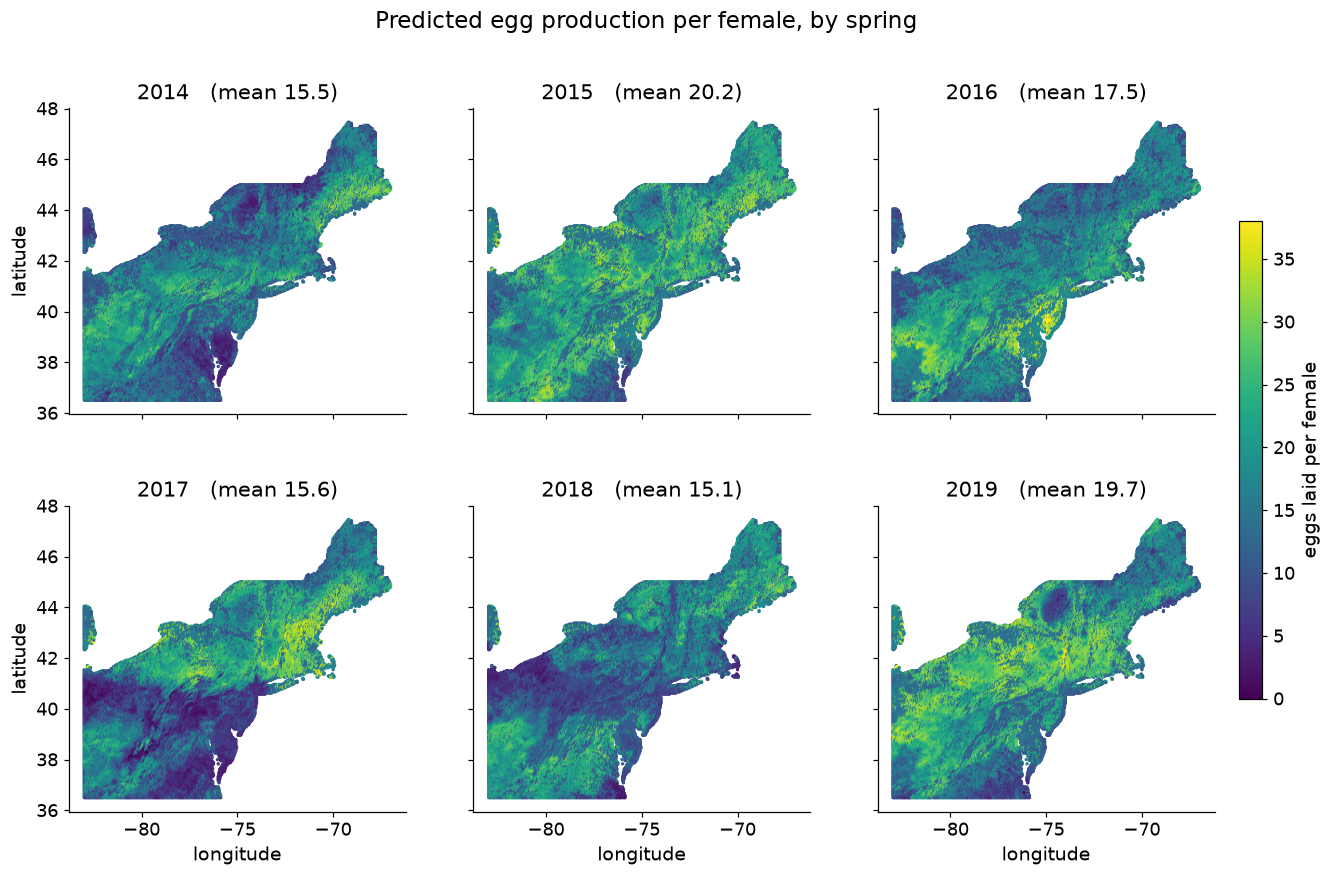

,mean,std,min,max
spring,,,,
2014,15.54,6.47,1,34
2015,20.16,6.49,3,38
2016,17.45,6.37,0,38
2017,15.58,8.25,0,38
2018,15.15,6.59,1,34
2019,19.74,7.36,0,38


In [17]:
# Egg production per female, mapped for every simulated spring on one shared
# colour scale so the panels are comparable year to year.
years = sorted(ne.offspring_year.unique())
vmin, vmax = ne.eggs.min(), ne.eggs.max()
fig, axes = plt.subplots(2, 3, figsize=(14, 8.6), sharex=True, sharey=True)
for ax, yr in zip(axes.ravel(), years):
    frame = ne[ne.offspring_year == yr]
    sc = ax.scatter(frame.lon, frame.lat, c=frame.eggs, s=1.4, cmap="viridis",
                    vmin=vmin, vmax=vmax)
    ax.set(title=f"{yr}   (mean {frame.eggs.mean():.1f})")
    ax.set_aspect(ASPECT)
for ax in axes[-1]:
    ax.set_xlabel("longitude")
for ax in axes[:, 0]:
    ax.set_ylabel("latitude")
fig.colorbar(sc, ax=axes, label="eggs laid per female", fraction=.02, pad=.02)
fig.suptitle("Predicted egg production per female, by spring", fontsize=15, y=.97)
plt.show()

display(ne.groupby("offspring_year").eggs.agg(["mean", "std", "min", "max"]).round(2)
        .rename_axis("spring"))

### By state

In [18]:
STATES = OUTPUTS / "conus_cell_states.parquet"
if STATES.exists():
    named = ne.merge(pd.read_parquet(STATES), on=["col", "row"], how="left")
    by_state = (named.groupby("NAME")
                .agg(cells=("offspring", "size"), eggs=("eggs", "mean"),
                     offspring=("offspring", "mean"),
                     cold_days=("no_egg_days_temperature", "mean"),
                     wet_days=("no_egg_days_precipitation", "mean"))
                .round(2).sort_values("offspring", ascending=False))
    by_state["cells"] = (by_state["cells"] // len(years)).astype(int)
    display(by_state)
else:
    print("cell-to-state table absent; skipping the state breakdown")

,cells,eggs,offspring,cold_days,wet_days
NAME,,,,,
Connecticut,811,21.52,18.62,5.28,4.01
New Hampshire,1556,19.53,17.32,6.51,4.42
Rhode Island,201,19.81,17.09,5.04,3.82
Massachusetts,1398,19.53,16.92,5.46,4.23
Maine,5762,18.56,16.90,6.69,4.31
New York,8204,16.99,15.09,6.11,4.58
West Virginia,3760,19.12,15.03,6.30,5.38
Vermont,1621,16.78,14.93,6.77,5.16
Pennsylvania,7173,17.41,14.89,6.50,4.55


### What drives a good year

Correlating each annual mean against the annual mean of the model's intermediate
quantities. Six years, so these are descriptive.

In [19]:
drivers = ne.groupby("offspring_year").agg(
    offspring=("offspring", "mean"), eggs=("eggs", "mean"),
    emergence=("emergence_doy", "mean"), cold_days=("no_egg_days_temperature", "mean"),
    wet_days=("no_egg_days_precipitation", "mean"))
display(drivers.round(2).rename_axis("spring"))
display(pd.DataFrame({"r vs annual mean offspring":
                      {c: round(float(np.corrcoef(drivers[c], drivers.offspring)[0, 1]), 3)
                       for c in ["eggs", "cold_days", "emergence", "wet_days"]}})
        .sort_values("r vs annual mean offspring", key=abs, ascending=False))

print(f"a female loses {ne.no_egg_days_temperature.mean():.2f} ± "
      f"{ne.no_egg_days_temperature.std():.2f} foraging days to cold, against "
      f"{ne.no_egg_days_precipitation.mean():.2f} ± "
      f"{ne.no_egg_days_precipitation.std():.2f} to rain")

,offspring,eggs,emergence,cold_days,wet_days
spring,,,,,
2014,13.07,15.54,133.38,7.41,5.04
2015,18.03,20.16,136.24,4.53,4.14
2016,14.55,17.45,131.93,6.64,4.04
2017,12.97,15.58,129.38,8.46,4.06
2018,12.38,15.15,123.18,8.36,5.11
2019,17.41,19.74,132.35,4.57,4.45


,r vs annual mean offspring
eggs,0.996
cold_days,-0.981
emergence,0.702
wet_days,-0.468


a female loses 6.66 ± 3.63 foraging days to cold, against 4.47 ± 2.06 to rain


### Cross-check: two independent input pipelines

Pennsylvania has weather and forage from a **different source** than the regional
run — the weather from a 1990–2024 PRISM export, the forage from a separate CDL
build. Where the two overlap they should agree, so this tests the acquisition
pipeline rather than the model.

In [20]:
PA_SIM = OUTPUTS / "pa_simulation_default.parquet"
if PA_SIM.exists():
    pa = pd.read_parquet(PA_SIM)
    m = pa.merge(ne[["col", "row", "offspring_year", "offspring", "emergence_doy"]],
                 on=["col", "row", "offspring_year"], suffixes=("_pa", "_ne"))
    print(f"  {len(m):,} matched cell-years on {m[['col','row']].drop_duplicates().shape[0]:,} cells")
    print(f"  emergence dates identical: {np.mean(m.emergence_doy_pa == m.emergence_doy_ne) * 100:.1f}%")
    print(f"  offspring correlation:     r = {np.corrcoef(m.offspring_pa, m.offspring_ne)[0, 1]:.3f}\n")
    print("  Emergence depends only on temperature, so its exactness confirms the two")
    print("  weather pipelines agree. The residual difference is the forage source")
    print("  stepping the egg rate across the forage threshold on a minority of cells.")
else:
    print("run: python scripts/simulate.py --region pennsylvania")

  44,664 matched cell-years on 7,444 cells
  emergence dates identical: 100.0%
  offspring correlation:     r = 0.955

  Emergence depends only on temperature, so its exactness confirms the two
  weather pipelines agree. The residual difference is the forage source
  stepping the egg rate across the forage threshold on a minority of cells.


---
# Summary

| | Result |
|---|---|
| **Egg production**, 51 observations, 17 sites | $R^2$ 0.510; slope 7.9 brood cells per predicted egg, p = 0.004; ICC 0.226 |
| **Whole model**, 6 annual counts, 1 site | $R^2$ 0.803, RMSE 7.52; slope 1.99, positive |
| **Simulation**, 44,756 cells × 6 years | mean 14.7 offspring per female across the Northeast |
| **Pipeline cross-check** | emergence 100% identical, offspring r = 0.955 between independent input sources |

$R^2$ is reported as the conditional value throughout — variance explained by the
fixed effects together with the random intercepts.

**The egg production sub-model is supported** by data with enough replication to
identify its variance components: 51 observations across 17 sites, with about a
quarter of the variance sitting between orchards (ICC 0.226).

**The whole-model evaluation rests on six annual counts from a single site.** The
fit is good and the effect is positive, but one observation per year cannot
separate a year effect from a residual, so the precision of the slope should not
be over-interpreted. A panel with real replication — several sites over several
years — would settle it, and is the structure the simulation produces and the
evaluation data lacks.

## Files this notebook used

| | |
|---|---|
| Inputs | `data/inputs/` — `observations/`, `weather/`, `forage/`, each with `PROVENANCE.json` |
| Parameters | `applebee/config.py` → `ModelParams`; per-run overrides in JSON or TOML |
| Model | `applebee/model.py`, sub-models in `applebee/` |
| Evaluations | `applebee/evaluation/centrella.py`, `applebee/evaluation/turley.py` |
| Regions | `applebee/datasets.py` |
| Acquisition | `scripts/fetch_prism.py`, `scripts/build_forage.py` |
| Simulation | `scripts/simulate.py` |
| Integrity | `applebee/provenance.py` |